Accuracy: 96.00%
Precision: 0.75
Recall: 0.75
F1 Score: 0.75
Specificity: 0.98


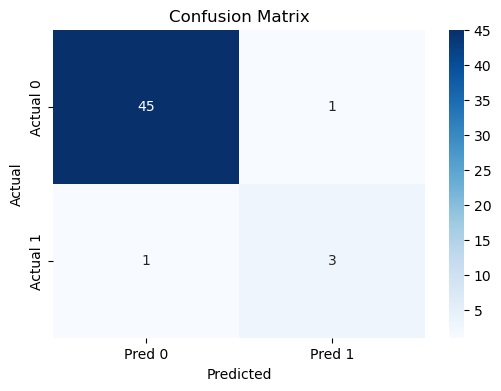

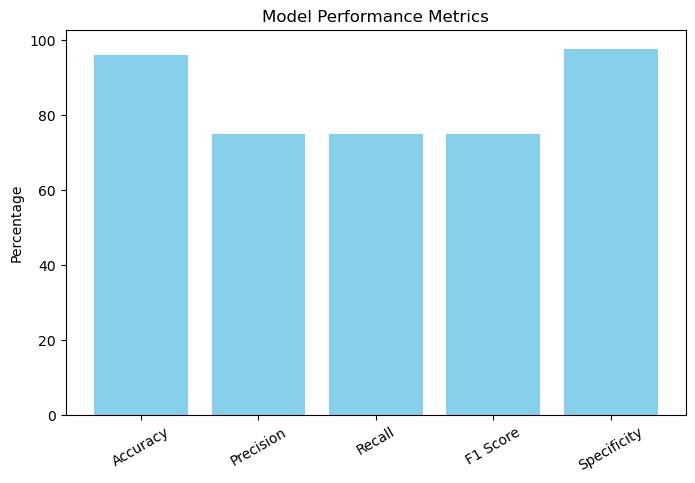

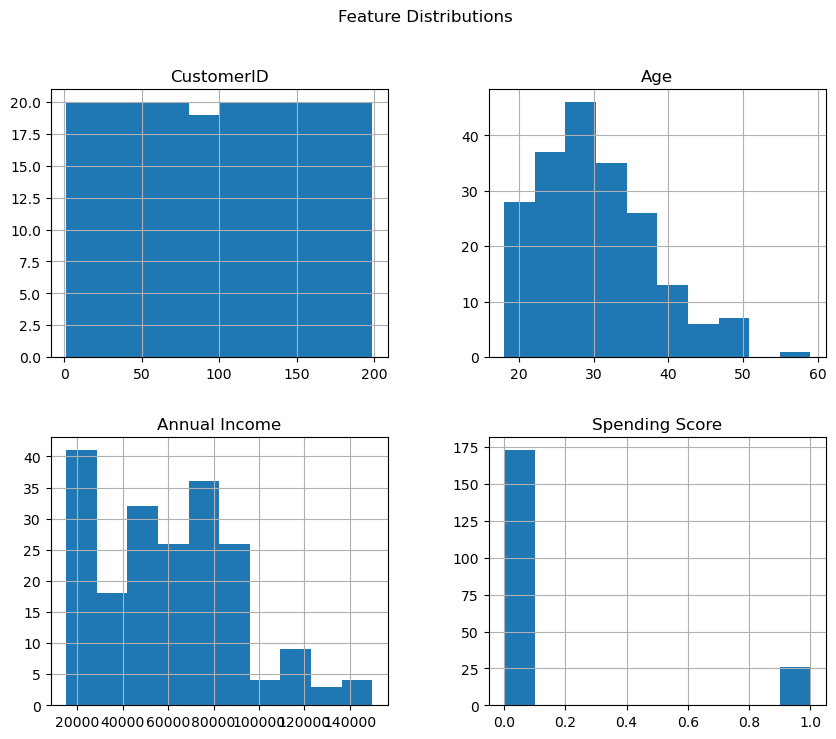

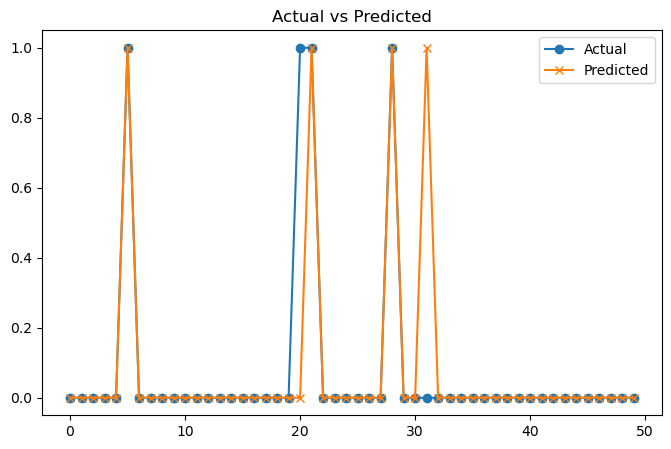


Enter values for the following features:
Predicted Output: 1


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Load dataset
df = pd.read_csv('data5.csv')

# Drop column (make sure name is correct: Genre or Gender)
df1 = df.drop("Genre", axis=1)

# Define features and target variable
y = df1.iloc[:, -1].values  # Target
X = df1.iloc[:, :-1].values  # Features

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2
)

# Train model
LR = LogisticRegression(max_iter=200)
LR.fit(X_train, y_train)

# Predictions
y_pred = LR.predict(X_test)

# Confusion matrix values
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = (tn + tp) * 100 / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

# Print metrics
print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}")
print(f"Specificity: {specificity:.2f}")

# ------------------ 📊 VISUALIZATIONS ------------------

# 1. Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 2. Metrics Bar Chart
metrics = {
    "Accuracy": accuracy,
    "Precision": precision * 100,
    "Recall": recall * 100,
    "F1 Score": f1_score * 100,
    "Specificity": specificity * 100
}

plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values(), color='skyblue')
plt.title("Model Performance Metrics")
plt.ylabel("Percentage")
plt.xticks(rotation=30)
plt.show()

# 3. Feature Distribution
df1.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions")
plt.show()

# 4. Actual vs Predicted Comparison
plt.figure(figsize=(8, 5))
plt.plot(y_test, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

# ------------------ 🔮 USER INPUT PREDICTION ------------------

print("\nEnter values for the following features:")

input_features = []
for i in range(X_train.shape[1]):
    val = float(input(f"Feature {i+1}: "))
    input_features.append(val)

# Convert to array
input_array = np.array(input_features).reshape(1, -1)

# Predict
prediction = LR.predict(input_array)[0]
print(f"Predicted Output: {prediction}")